# IE 306 — Assignment 2
## Coordinated Traffic Corridor Simulation (SimPy)

This notebook implements a discrete-event simulation for the two-intersection corridor with:
- Fixed-time signals at A and B
- Coordination offset scenarios (0 s and 20 s)
- Bus queue priority (non-preemptive)
- Emergency preemption and cycle resumption
- Finite link storage and downstream blocking at A
- 20 replications, 900 s warm-up, 7200 s run length
- 95% confidence intervals for all KPIs

In [1]:
# If needed, uncomment and run once:
# %pip install simpy numpy pandas matplotlib seaborn simpy-stats

from dataclasses import dataclass
import heapq
import math
import numpy as np
import pandas as pd
import simpy
from simpy_stats import Stats
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

RUN_LENGTH = 7200.0
WARMUP = 900.0
REPLICATIONS = 20

CYCLE = 90.0
G_NS = 45.0
AMBER = 4.0
G_WE = 37.0

L = 300.0
V_FREE = 15.0
FREE_FLOW_TT = L / V_FREE
N_MAX = 40

LAMBDA_S = 900 / 3600.0
LAMBDA_WE = 400 / 3600.0

P_CAR = 0.85
P_BUS = 0.10
P_EMER = 0.05

P_STRAIGHT_A = 0.70
P_STRAIGHT_B = 0.80

MEAN_SERVICE = 2.0
PREEMPT_CLEARANCE = 4.0
PREEMPT_MIN_NS = 10.0

SCENARIOS = [
    {'id': 1, 'name': 'Uncoordinated_NoEmergency', 'offset_B': 0.0, 'emergency_enabled': False},
    {'id': 2, 'name': 'Coordinated_NoEmergency', 'offset_B': 20.0, 'emergency_enabled': False},
    {'id': 3, 'name': 'Coordinated_WithEmergency', 'offset_B': 20.0, 'emergency_enabled': True},
]

MASTER_SEED = 20260407

In [2]:
@dataclass
class Vehicle:
    vid: int
    kind: str  # car, bus, emergency, we
    entry_time: float
    approach_arrival: float
    total_delay: float = 0.0
    turn_e_at_A: bool = False
    turn_e_at_B: bool = False

    @property
    def is_emergency(self):
        return self.kind == 'emergency'

    @property
    def is_bus(self):
        return self.kind == 'bus'


class TimeWeightedStat:
    def __init__(self, warmup, end_time, initial=0.0):
        self.warmup = warmup
        self.end_time = end_time
        self.last_t = 0.0
        self.last_v = float(initial)
        self.area = 0.0
        self.max_v = float(initial)

    def update(self, t, new_value):
        t = float(t)
        if t < self.last_t:
            return

        seg_start = max(self.last_t, self.warmup)
        seg_end = min(t, self.end_time)
        if seg_end > seg_start:
            self.area += self.last_v * (seg_end - seg_start)
            self.max_v = max(self.max_v, self.last_v)

        self.last_t = t
        self.last_v = float(new_value)
        if t >= self.warmup:
            self.max_v = max(self.max_v, self.last_v)

    def finalize(self):
        self.update(self.end_time, self.last_v)

    @property
    def mean(self):
        horizon = self.end_time - self.warmup
        return self.area / horizon if horizon > 0 else np.nan


class Metrics:
    def __init__(self, warmup, run_length, cycle_len):
        self.warmup = warmup
        self.run_length = run_length
        self.cycle_len = cycle_len

        # simpy-stats registry (lecture-style clean statistics collection)
        self.stats = Stats()
        self.delay_through_tally = self.stats.tally('delay_through_s')
        self.delay_we_tally = self.stats.tally('delay_we_s')
        self.preemption_counter = self.stats.counter('preemption_events')
        self.recovery_tally = self.stats.tally('recovery_time_s')

        # Keep explicit time-weighted trackers for queue/link levels and max queue KPIs
        self.queue_stats = {
            'A_NS': TimeWeightedStat(warmup, run_length, 0),
            'B_NS': TimeWeightedStat(warmup, run_length, 0),
            'A_WE': TimeWeightedStat(warmup, run_length, 0),
            'B_WE': TimeWeightedStat(warmup, run_length, 0),
        }
        self.link_occ = TimeWeightedStat(warmup, run_length, 0)

        self.throughput_north_count = 0
        self.blocking_bins = set()

        # Approach accounting for utilization and rho checks
        self.served_counts = {
            'A_NS': 0,
            'B_NS': 0,
            'A_WE': 0,
            'B_WE': 0,
        }
        self.service_time_accum = {
            'A_NS': 0.0,
            'B_NS': 0.0,
            'A_WE': 0.0,
            'B_WE': 0.0,
        }

        self.stats_snapshot = {}

    def update_queue(self, key, t, value):
        self.queue_stats[key].update(t, value)

    def update_link(self, t, value):
        self.link_occ.update(t, value)

    def mark_blocking(self, t):
        if t >= self.warmup:
            b = int((t - self.warmup) // self.cycle_len)
            self.blocking_bins.add(b)

    def record_service(self, approach_key, service_start_time, service_time):
        if approach_key not in self.served_counts:
            return
        if service_start_time >= self.warmup:
            self.served_counts[approach_key] += 1
            self.service_time_accum[approach_key] += float(service_time)

    def record_delay_through(self, delay, t):
        if t >= self.warmup:
            self.delay_through_tally.observe(float(delay), t=t)

    def record_delay_we(self, delay, t):
        if t >= self.warmup:
            self.delay_we_tally.observe(float(delay), t=t)

    def record_preemption(self, t):
        if t >= self.warmup:
            self.preemption_counter.inc()

    def record_recovery(self, recovery_time, t):
        if t >= self.warmup:
            self.recovery_tally.observe(float(recovery_time), t=t)

    def finalize(self):
        for s in self.queue_stats.values():
            s.finalize()
        self.link_occ.finalize()
        self.stats_snapshot = dict(self.stats.finalize(self.run_length))

    def as_replication_row(self):
        total_bins = int((self.run_length - self.warmup) // self.cycle_len)
        horizon = self.run_length - self.warmup
        mu_service = 1.0 / MEAN_SERVICE

        util_A_NS = self.service_time_accum['A_NS'] / horizon if horizon > 0 else np.nan
        util_B_NS = self.service_time_accum['B_NS'] / horizon if horizon > 0 else np.nan
        util_A_WE = self.service_time_accum['A_WE'] / horizon if horizon > 0 else np.nan
        util_B_WE = self.service_time_accum['B_WE'] / horizon if horizon > 0 else np.nan

        lambda_A_NS = self.served_counts['A_NS'] / horizon if horizon > 0 else np.nan
        lambda_B_NS = self.served_counts['B_NS'] / horizon if horizon > 0 else np.nan
        lambda_A_WE = self.served_counts['A_WE'] / horizon if horizon > 0 else np.nan
        lambda_B_WE = self.served_counts['B_WE'] / horizon if horizon > 0 else np.nan

        rho_A_NS = lambda_A_NS / mu_service if mu_service > 0 else np.nan
        rho_B_NS = lambda_B_NS / mu_service if mu_service > 0 else np.nan
        rho_A_WE = lambda_A_WE / mu_service if mu_service > 0 else np.nan
        rho_B_WE = lambda_B_WE / mu_service if mu_service > 0 else np.nan

        served_we_total = self.served_counts['A_WE'] + self.served_counts['B_WE']
        lambda_we_total = served_we_total / horizon if horizon > 0 else np.nan

        return {
            'delay_through_s': self.stats_snapshot.get('delay_through_s.mean', np.nan),
            'delay_we_s': self.stats_snapshot.get('delay_we_s.mean', np.nan),
            'avg_q_A_NS': self.queue_stats['A_NS'].mean,
            'max_q_A_NS': self.queue_stats['A_NS'].max_v,
            'avg_q_B_NS': self.queue_stats['B_NS'].mean,
            'max_q_B_NS': self.queue_stats['B_NS'].max_v,
            'avg_q_A_WE': self.queue_stats['A_WE'].mean,
            'max_q_A_WE': self.queue_stats['A_WE'].max_v,
            'avg_q_B_WE': self.queue_stats['B_WE'].mean,
            'max_q_B_WE': self.queue_stats['B_WE'].max_v,
            'throughput_north_vph': self.throughput_north_count * 3600.0 / (self.run_length - self.warmup),
            'avg_link_occupancy': self.link_occ.mean,
            'blocking_frequency': len(self.blocking_bins) / total_bins if total_bins > 0 else np.nan,
            'preemption_count': self.stats_snapshot.get('preemption_events.count', 0.0),
            'recovery_time_s': self.stats_snapshot.get('recovery_time_s.mean', np.nan),
            'served_A_NS': self.served_counts['A_NS'],
            'served_B_NS': self.served_counts['B_NS'],
            'served_A_WE': self.served_counts['A_WE'],
            'served_B_WE': self.served_counts['B_WE'],
            'served_WE_total': served_we_total,
            'lambda_A_NS': lambda_A_NS,
            'lambda_B_NS': lambda_B_NS,
            'lambda_A_WE': lambda_A_WE,
            'lambda_B_WE': lambda_B_WE,
            'lambda_WE_total': lambda_we_total,
            'util_A_NS': util_A_NS,
            'util_B_NS': util_B_NS,
            'util_A_WE': util_A_WE,
            'util_B_WE': util_B_WE,
            'rho_A_NS': rho_A_NS,
            'rho_B_NS': rho_B_NS,
            'rho_A_WE': rho_A_WE,
            'rho_B_WE': rho_B_WE,
        }

In [3]:
class SignalController:
    REGULAR_PHASES = [
        ('NS_GREEN', G_NS),
        ('ALL_RED', AMBER),
        ('WE_GREEN', G_WE),
        ('ALL_RED', AMBER),
    ]

    def __init__(self, env, name, offset, emergency_enabled, metrics):
        self.env = env
        self.name = name
        self.offset = offset
        self.emergency_enabled = emergency_enabled
        self.metrics = metrics

        self.phase_name = None
        self.phase_idx = None
        self._handling_preemption = False

        self.state_event = env.event()
        self.proc = env.process(self.run())

    def _notify(self):
        if not self.state_event.triggered:
            self.state_event.succeed()
        self.state_event = self.env.event()

    def _initial_phase(self):
        cycle = CYCLE
        pos = (cycle - self.offset) % cycle

        boundary = 0.0
        for idx, (_, dur) in enumerate(self.REGULAR_PHASES):
            if pos < boundary + dur:
                elapsed = pos - boundary
                rem = dur - elapsed
                return idx, rem
            boundary += dur

        return 0, G_NS

    def is_ns_green(self):
        return self.phase_name == 'NS_GREEN'

    def is_we_green(self):
        return self.phase_name == 'WE_GREEN'

    def request_preemption(self):
        if not self.emergency_enabled:
            return
        if self.phase_name == 'NS_GREEN':
            return
        if self._handling_preemption:
            return
        if self.proc.is_alive:
            try:
                self.proc.interrupt('preempt')
            except RuntimeError:
                pass

    def _timeout_ignore_preempt(self, duration):
        end_t = self.env.now + max(0.0, duration)
        while self.env.now < end_t - 1e-9:
            rem = end_t - self.env.now
            try:
                yield self.env.timeout(rem)
            except simpy.Interrupt as interrupt:
                if interrupt.cause == 'preempt':
                    continue
                raise

    def run(self):
        phase_idx, remaining = self._initial_phase()

        while True:
            phase_name, _ = self.REGULAR_PHASES[phase_idx]
            self.phase_idx = phase_idx
            self.phase_name = phase_name
            self._notify()

            start = self.env.now
            try:
                yield self.env.timeout(remaining)
                phase_idx = (phase_idx + 1) % len(self.REGULAR_PHASES)
                remaining = self.REGULAR_PHASES[phase_idx][1]

            except simpy.Interrupt as interrupt:
                if interrupt.cause != 'preempt' or not self.emergency_enabled or self.phase_name == 'NS_GREEN':
                    elapsed = self.env.now - start
                    remaining = max(0.0, remaining - elapsed)
                    continue

                elapsed = self.env.now - start
                interrupted_idx = phase_idx
                interrupted_remaining = max(0.0, remaining - elapsed)

                self.metrics.record_preemption(self.env.now)

                self._handling_preemption = True
                try:
                    self.phase_name = 'ALL_RED'
                    self.phase_idx = -1
                    self._notify()
                    yield from self._timeout_ignore_preempt(PREEMPT_CLEARANCE)

                    self.phase_name = 'NS_GREEN'
                    self.phase_idx = -2
                    self._notify()
                    yield from self._timeout_ignore_preempt(PREEMPT_MIN_NS)

                    recovery_start = self.env.now

                    if interrupted_remaining > 1e-9:
                        phase_idx = interrupted_idx
                        remaining = interrupted_remaining
                        self.phase_name = self.REGULAR_PHASES[phase_idx][0]
                        self.phase_idx = phase_idx
                        self._notify()
                        yield from self._timeout_ignore_preempt(remaining)

                    self.metrics.record_recovery(self.env.now - recovery_start, self.env.now)

                    phase_idx = (interrupted_idx + 1) % len(self.REGULAR_PHASES)
                    remaining = self.REGULAR_PHASES[phase_idx][1]
                finally:
                    self._handling_preemption = False


class CorridorLink:
    def __init__(self, env, metrics, travel_rng, noise_rng, downstream_intersection=None):
        self.env = env
        self.metrics = metrics
        self.travel_rng = travel_rng
        self.noise_rng = noise_rng
        self.downstream_intersection = downstream_intersection

        self.capacity = N_MAX
        self.occupancy = 0
        self.change_event = env.event()

    def _notify(self):
        if not self.change_event.triggered:
            self.change_event.succeed()
        self.change_event = self.env.event()

    def _travel_time(self):
        n = min(self.occupancy, self.capacity - 1e-3)
        base = FREE_FLOW_TT / (1.0 - n / self.capacity)
        noise = max(0.5, self.noise_rng.normal(loc=1.0, scale=0.02))
        return base * noise

    def can_enter(self):
        return self.occupancy < self.capacity

    def send_to_B(self, vehicle):
        self.occupancy += 1
        self.metrics.update_link(self.env.now, self.occupancy)
        self._notify()

        tt = self._travel_time()
        yield self.env.timeout(tt)

        self.occupancy -= 1
        self.metrics.update_link(self.env.now, self.occupancy)
        self._notify()

        vehicle.approach_arrival = self.env.now
        self.downstream_intersection.enqueue_ns(vehicle)


class Intersection:
    def __init__(self, env, name, signal, metrics, service_rng, turn_rng, link=None):
        self.env = env
        self.name = name
        self.signal = signal
        self.metrics = metrics
        self.service_rng = service_rng
        self.turn_rng = turn_rng
        self.link = link

        self.ns_queue = []
        self.we_queue = []
        self.seq = 0
        self.queue_event = env.event()

        self.env.process(self.ns_server())
        self.env.process(self.we_server())

    def _queue_key_ns(self):
        return f'{self.name}_NS'

    def _queue_key_we(self):
        return f'{self.name}_WE'

    def _notify_queue(self):
        if not self.queue_event.triggered:
            self.queue_event.succeed()
        self.queue_event = self.env.event()

    def enqueue_ns(self, vehicle):
        if self.name == 'B':
            vehicle.turn_e_at_B = self.turn_rng.random() > P_STRAIGHT_B

        prio = 0 if vehicle.is_emergency else (1 if vehicle.is_bus else 2)
        heapq.heappush(self.ns_queue, (prio, self.seq, vehicle))
        self.seq += 1

        self.metrics.update_queue(self._queue_key_ns(), self.env.now, len(self.ns_queue))

        if vehicle.is_emergency and self.signal.emergency_enabled and not self.signal.is_ns_green():
            self.signal.request_preemption()

        self._notify_queue()

    def enqueue_we(self, vehicle):
        heapq.heappush(self.we_queue, (2, self.seq, vehicle))
        self.seq += 1
        self.metrics.update_queue(self._queue_key_we(), self.env.now, len(self.we_queue))
        self._notify_queue()

    def ns_server(self):
        while True:
            if not self.ns_queue:
                wait_for = [self.queue_event, self.signal.state_event]
                if self.link is not None:
                    wait_for.append(self.link.change_event)
                yield self.env.any_of(wait_for)
                continue

            if not self.signal.is_ns_green():
                yield self.signal.state_event
                continue

            _, _, veh = self.ns_queue[0]

            blocked = (
                self.name == 'A'
                and veh.turn_e_at_A is False
                and not veh.is_emergency
                and self.link is not None
                and not self.link.can_enter()
            )

            if blocked:
                self.metrics.mark_blocking(self.env.now)
                yield self.env.any_of([self.signal.state_event, self.link.change_event])
                continue

            heapq.heappop(self.ns_queue)
            self.metrics.update_queue(self._queue_key_ns(), self.env.now, len(self.ns_queue))

            wait = self.env.now - veh.approach_arrival
            veh.total_delay += wait

            service_start = self.env.now
            service_t = self.service_rng.exponential(MEAN_SERVICE)
            self.metrics.record_service(self._queue_key_ns(), service_start, service_t)
            yield self.env.timeout(service_t)

            if self.name == 'A':
                if veh.turn_e_at_A:
                    pass
                else:
                    self.env.process(self.link.send_to_B(veh))
            else:
                if not veh.turn_e_at_B:
                    # Gate on exit time (env.now), not entry_time, so vehicles
                    # that arrived before warmup but exit after are included.
                    if self.env.now >= WARMUP:
                        self.metrics.record_delay_through(veh.total_delay, self.env.now)
                        self.throughput_increment()

    def throughput_increment(self):
        self.metrics.throughput_north_count += 1

    def we_server(self):
        while True:
            if not self.we_queue:
                yield self.env.any_of([self.queue_event, self.signal.state_event])
                continue

            if not self.signal.is_we_green():
                yield self.signal.state_event
                continue

            _, _, veh = heapq.heappop(self.we_queue)
            self.metrics.update_queue(self._queue_key_we(), self.env.now, len(self.we_queue))

            wait = self.env.now - veh.approach_arrival
            service_start = self.env.now
            service_t = self.service_rng.exponential(MEAN_SERVICE)
            self.metrics.record_service(self._queue_key_we(), service_start, service_t)
            yield self.env.timeout(service_t)

            # Gate on exit time so W/E vehicles exiting after warmup are included.
            if self.env.now >= WARMUP:
                self.metrics.record_delay_we(wait, self.env.now)

In [4]:
def spawn_rngs(master_seed, scenario_id, replication_id):
    ss = np.random.SeedSequence([master_seed, scenario_id, replication_id])
    children = ss.spawn(9)
    return {
        'arrival_s': np.random.default_rng(children[0]),
        'arrival_we_A': np.random.default_rng(children[1]),
        'arrival_we_B': np.random.default_rng(children[2]),
        'classify': np.random.default_rng(children[3]),
        'turn_A': np.random.default_rng(children[4]),
        'turn_B': np.random.default_rng(children[5]),
        'service_A': np.random.default_rng(children[6]),
        'service_B': np.random.default_rng(children[7]),
        'link_noise': np.random.default_rng(children[8]),
    }


def south_arrivals(env, inter_A, rng_arr, rng_cls, rng_turn_A, emergency_enabled):
    vid = 0
    while True:
        dt = rng_arr.exponential(1.0 / LAMBDA_S)
        yield env.timeout(dt)
        if env.now > RUN_LENGTH:
            break

        u = rng_cls.random()
        if emergency_enabled:
            if u < P_CAR:
                kind = 'car'
            elif u < P_CAR + P_BUS:
                kind = 'bus'
            else:
                kind = 'emergency'
        else:
            kind = 'car' if u < (P_CAR + P_EMER) else 'bus'

        veh = Vehicle(
            vid=vid,
            kind=kind,
            entry_time=env.now,
            approach_arrival=env.now,
            turn_e_at_A=(rng_turn_A.random() > P_STRAIGHT_A),
        )
        vid += 1
        inter_A.enqueue_ns(veh)


def we_arrivals(env, intersection, rng_arr):
    vid = 0
    while True:
        dt = rng_arr.exponential(1.0 / LAMBDA_WE)
        yield env.timeout(dt)
        if env.now > RUN_LENGTH:
            break

        veh = Vehicle(
            vid=vid,
            kind='we',
            entry_time=env.now,
            approach_arrival=env.now,
        )
        vid += 1
        intersection.enqueue_we(veh)


def run_replication(scenario, rep_id, master_seed=MASTER_SEED):
    env = simpy.Environment()
    rngs = spawn_rngs(master_seed, scenario['id'], rep_id)

    metrics = Metrics(WARMUP, RUN_LENGTH, CYCLE)

    signal_A = SignalController(env, 'A', offset=0.0, emergency_enabled=scenario['emergency_enabled'], metrics=metrics)
    signal_B = SignalController(env, 'B', offset=scenario['offset_B'], emergency_enabled=scenario['emergency_enabled'], metrics=metrics)

    link = CorridorLink(env, metrics, travel_rng=rngs['service_A'], noise_rng=rngs['link_noise'])

    inter_A = Intersection(
        env=env,
        name='A',
        signal=signal_A,
        metrics=metrics,
        service_rng=rngs['service_A'],
        turn_rng=rngs['turn_A'],
        link=link,
    )

    inter_B = Intersection(
        env=env,
        name='B',
        signal=signal_B,
        metrics=metrics,
        service_rng=rngs['service_B'],
        turn_rng=rngs['turn_B'],
        link=None,
    )

    link.downstream_intersection = inter_B

    env.process(south_arrivals(env, inter_A, rngs['arrival_s'], rngs['classify'], rngs['turn_A'], scenario['emergency_enabled']))
    env.process(we_arrivals(env, inter_A, rngs['arrival_we_A']))
    env.process(we_arrivals(env, inter_B, rngs['arrival_we_B']))

    env.run(until=RUN_LENGTH)
    metrics.finalize()

    row = metrics.as_replication_row()
    row['scenario'] = scenario['name']
    row['replication'] = rep_id
    return row


def mean_ci(series, z=1.96):
    x = pd.Series(series).dropna()
    n = len(x)
    if n == 0:
        return np.nan, np.nan, np.nan
    mean = x.mean()
    if n == 1:
        return mean, np.nan, np.nan
    se = x.std(ddof=1) / math.sqrt(n)
    h = z * se
    return mean, mean - h, mean + h


def summarize_with_ci(df_rep):
    records = []
    metric_cols = [
        'delay_through_s', 'delay_we_s',
        'avg_q_A_NS', 'max_q_A_NS', 'avg_q_B_NS', 'max_q_B_NS',
        'avg_q_A_WE', 'max_q_A_WE', 'avg_q_B_WE', 'max_q_B_WE',
        'throughput_north_vph', 'avg_link_occupancy', 'blocking_frequency',
        'preemption_count', 'recovery_time_s'
    ]

    for scen, g in df_rep.groupby('scenario'):
        for m in metric_cols:
            mean, lo, hi = mean_ci(g[m])
            records.append({
                'scenario': scen,
                'metric': m,
                'mean': mean,
                'ci95_low': lo,
                'ci95_high': hi,
            })

    return pd.DataFrame(records)

In [5]:
# Run all scenarios and replications
rep_rows = []
for s in SCENARIOS:
    for r in range(1, REPLICATIONS + 1):
        rep_rows.append(run_replication(s, r, master_seed=MASTER_SEED))

df_rep = pd.DataFrame(rep_rows)
df_ci = summarize_with_ci(df_rep)

print('Replications completed:', len(df_rep))
display(df_rep.head())

Replications completed: 60


,delay_through_s,delay_we_s,avg_q_A_NS,max_q_A_NS,avg_q_B_NS,max_q_B_NS,avg_q_A_WE,max_q_A_WE,avg_q_B_WE,max_q_B_WE,...,util_A_NS,util_B_NS,util_A_WE,util_B_WE,rho_A_NS,rho_B_NS,rho_A_WE,rho_B_WE,scenario,replication
0,98.354460,22.572954,19.722817,71.0,4.488614,21.0,2.345836,13.0,2.570652,14.0,...,0.503877,0.349451,0.199185,0.220912,0.505714,0.358413,0.217460,0.218095,Uncoordinated_NoEmergency,1
1,109.030652,22.363567,22.195596,60.0,4.265101,17.0,2.188901,13.0,2.827606,15.0,...,0.506559,0.348874,0.209990,0.233530,0.502857,0.354603,0.212063,0.236190,Uncoordinated_NoEmergency,2
2,230.319837,20.906249,53.052140,125.0,4.721977,22.0,2.340165,11.0,2.199406,12.0,...,0.515556,0.353693,0.226980,0.215793,0.504444,0.348254,0.220952,0.212381,Uncoordinated_NoEmergency,3
3,105.461275,21.948639,20.379629,47.0,4.704870,20.0,2.424974,14.0,2.480821,13.0,...,0.495219,0.366317,0.225296,0.223820,0.519048,0.372381,0.222540,0.224444,Uncoordinated_NoEmergency,4
4,79.006256,22.833903,14.288297,49.0,4.684704,18.0,2.372184,12.0,2.680880,11.0,...,0.486668,0.356849,0.227326,0.245328,0.513333,0.362540,0.216190,0.225079,Uncoordinated_NoEmergency,5


In [6]:
# KPI tables (mean and 95% CI)
main_kpis = [
    'delay_through_s', 'delay_we_s',
    'throughput_north_vph', 'avg_link_occupancy', 'blocking_frequency',
    'preemption_count', 'recovery_time_s'
]

queue_kpis = [
    'avg_q_A_NS', 'max_q_A_NS', 'avg_q_B_NS', 'max_q_B_NS',
    'avg_q_A_WE', 'max_q_A_WE', 'avg_q_B_WE', 'max_q_B_WE'
]

display(df_ci[df_ci['metric'].isin(main_kpis)].sort_values(['metric', 'scenario']))
display(df_ci[df_ci['metric'].isin(queue_kpis)].sort_values(['metric', 'scenario']))

,scenario,metric,mean,ci95_low,ci95_high
11,Coordinated_NoEmergency,avg_link_occupancy,4.251420,4.196187,4.306653
26,Coordinated_WithEmergency,avg_link_occupancy,4.255374,4.193831,4.316917
41,Uncoordinated_NoEmergency,avg_link_occupancy,4.298408,4.235099,4.361716
12,Coordinated_NoEmergency,blocking_frequency,0.000000,0.000000,0.000000
27,Coordinated_WithEmergency,blocking_frequency,0.000000,0.000000,0.000000
42,Uncoordinated_NoEmergency,blocking_frequency,0.000000,0.000000,0.000000
0,Coordinated_NoEmergency,delay_through_s,96.270044,84.395053,108.145036
15,Coordinated_WithEmergency,delay_through_s,70.207281,61.785247,78.629316
30,Uncoordinated_NoEmergency,delay_through_s,121.811881,102.575932,141.047829
1,Coordinated_NoEmergency,delay_we_s,21.464145,21.091087,21.837203


,scenario,metric,mean,ci95_low,ci95_high
2,Coordinated_NoEmergency,avg_q_A_NS,21.286083,18.238826,24.333341
17,Coordinated_WithEmergency,avg_q_A_NS,13.248706,11.186255,15.311158
32,Uncoordinated_NoEmergency,avg_q_A_NS,24.344816,19.484983,29.204649
6,Coordinated_NoEmergency,avg_q_A_WE,2.398301,2.306941,2.489661
21,Coordinated_WithEmergency,avg_q_A_WE,2.582496,2.487287,2.677704
36,Uncoordinated_NoEmergency,avg_q_A_WE,2.403450,2.315762,2.491139
4,Coordinated_NoEmergency,avg_q_B_NS,2.136759,2.005239,2.268280
19,Coordinated_WithEmergency,avg_q_B_NS,3.171630,2.924597,3.418663
34,Uncoordinated_NoEmergency,avg_q_B_NS,4.614999,4.431178,4.798820
8,Coordinated_NoEmergency,avg_q_B_WE,2.390127,2.328933,2.451320


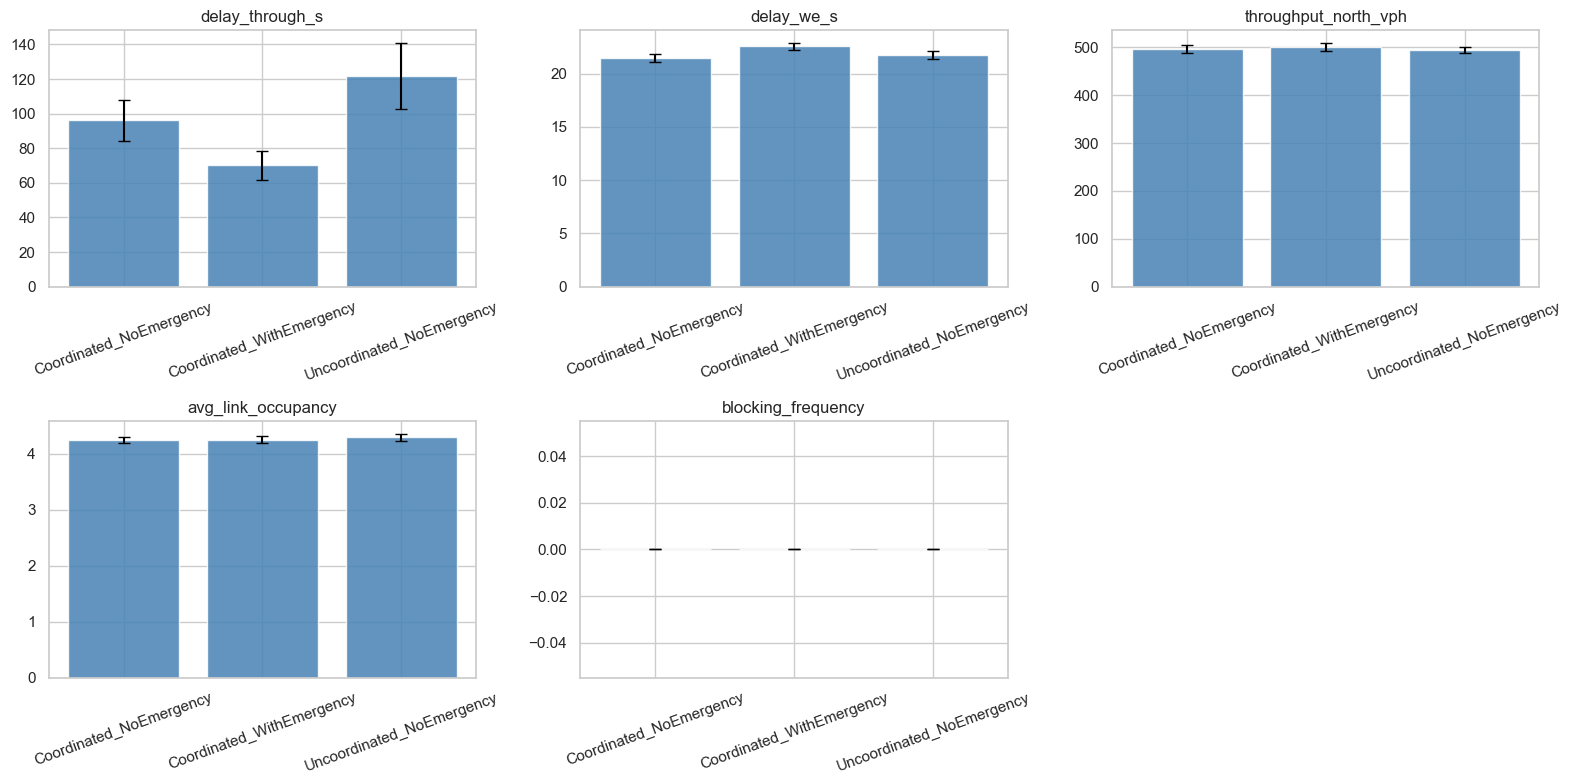

In [7]:
# Comparative figures
plot_metrics = ['delay_through_s', 'delay_we_s', 'throughput_north_vph', 'avg_link_occupancy', 'blocking_frequency']
plot_df = df_ci[df_ci['metric'].isin(plot_metrics)].copy()

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, m in enumerate(plot_metrics):
    ax = axes[i]
    d = plot_df[plot_df['metric'] == m].sort_values('scenario')
    y = d['mean'].values
    lo = d['ci95_low'].values
    hi = d['ci95_high'].values
    yerr = np.vstack([y - lo, hi - y])

    ax.bar(d['scenario'], y, color='steelblue', alpha=0.85)
    ax.errorbar(d['scenario'], y, yerr=yerr, fmt='none', ecolor='black', capsize=4)
    ax.set_title(m)
    ax.tick_params(axis='x', rotation=20)

for j in range(len(plot_metrics), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

## Conceptual Flow (for report section)
```mermaid
flowchart TD
    S[South Arrival at A] --> C{Vehicle Type}
    C -->|Car/Bus| QA[Join A N/S Queue]
    C -->|Emergency| EA[Emergency at A]
    EA --> PA{A N/S Green?}
    PA -->|No| PRA[Preempt A: all-red 4s then N/S green]
    PA -->|Yes| QA
    QA --> SA[Serve at A]
    SA --> TA{Turn East at A?}
    TA -->|Yes| EXA[Exit System]
    TA -->|No| BL{Link Full?}
    BL -->|Yes and non-emergency| WA[Wait at A]
    BL -->|No or emergency| LK[Enter A-B Link]
    LK --> BQ[Join B N/S Queue]
    BQ --> SB[Serve at B]
    SB --> TB{Turn East at B?}
    TB -->|Yes| EXB1[Exit East]
    TB -->|No| EXB2[Exit North (throughput)]

    WEA[W/E Arrival at A] --> QWEA[Join A W/E Queue] --> SWEA[Serve if W/E green] --> EXWEA[Exit East]
    WEB[W/E Arrival at B] --> QWEB[Join B W/E Queue] --> SWEB[Serve if W/E green] --> EXWEB[Exit East]
```

## Notes / Assumptions
- Delay is measured as queue waiting time before service starts at each approach.
- Through-traffic delay is total waiting delay for vehicles that enter at south and exit north at B.
- Emergency preemption inserts 4 s all-red and 10 s N/S green, then resumes interrupted phase remainder.
- Recovery time is measured from end of emergency green to completion of resumed interrupted remainder.
- In scenarios without emergencies, emergency share is reassigned to cars (car 90%, bus 10%).
- Link travel time includes small multiplicative noise (mean 1.0, sd 0.02) using a separate RNG stream.

## Auto-generated comparative discussion (report-ready)
Use the next code cell output as draft text for Deliverable 4(d).

In [8]:
def metric_mean(scenario_name, metric):
    x = df_ci[(df_ci['scenario'] == scenario_name) & (df_ci['metric'] == metric)]['mean']
    return float(x.iloc[0]) if len(x) else np.nan

sc1 = 'Uncoordinated_NoEmergency'
sc2 = 'Coordinated_NoEmergency'
sc3 = 'Coordinated_WithEmergency'

comparison_metrics = [
    'delay_through_s', 'delay_we_s', 'throughput_north_vph',
    'avg_link_occupancy', 'blocking_frequency'
]

rows = []
for m in comparison_metrics:
    v1 = metric_mean(sc1, m)
    v2 = metric_mean(sc2, m)
    v3 = metric_mean(sc3, m)
    change_21 = 100 * (v2 - v1) / v1 if np.isfinite(v1) and abs(v1) > 1e-12 else np.nan
    change_32 = 100 * (v3 - v2) / v2 if np.isfinite(v2) and abs(v2) > 1e-12 else np.nan
    rows.append({
        'metric': m,
        'S1_mean': v1,
        'S2_mean': v2,
        'S3_mean': v3,
        'pct_change_S2_vs_S1': change_21,
        'pct_change_S3_vs_S2': change_32,
    })

df_cmp = pd.DataFrame(rows)
display(df_cmp)

# Most affected KPI by emergency preemption (Scenario 3 vs 2)
most_affected = df_cmp.loc[df_cmp['pct_change_S3_vs_S2'].abs().idxmax()]

pre_count = metric_mean(sc3, 'preemption_count')
rec_time = metric_mean(sc3, 'recovery_time_s')

print('\n--- Draft comparative discussion ---')
print(
    f"Coordination effect (S2 vs S1): Through-delay changed by "
    f"{df_cmp.loc[df_cmp.metric=='delay_through_s','pct_change_S2_vs_S1'].iloc[0]:.1f}% and "
    f"northbound throughput changed by "
    f"{df_cmp.loc[df_cmp.metric=='throughput_north_vph','pct_change_S2_vs_S1'].iloc[0]:.1f}%."
)
print(
    f"Emergency effect (S3 vs S2): Through-delay changed by "
    f"{df_cmp.loc[df_cmp.metric=='delay_through_s','pct_change_S3_vs_S2'].iloc[0]:.1f}% and "
    f"blocking frequency changed by "
    f"{df_cmp.loc[df_cmp.metric=='blocking_frequency','pct_change_S3_vs_S2'].iloc[0]:.1f}%."
)
print(
    f"Most affected KPI by emergency preemption appears to be '{most_affected['metric']}' "
    f"with {most_affected['pct_change_S3_vs_S2']:.1f}% change from Scenario 2 to 3."
)
print(
    f"Scenario 3 operational detail: mean preemptions per replication = {pre_count:.2f}, "
    f"mean recovery time = {rec_time:.2f} s."
)

,metric,S1_mean,S2_mean,S3_mean,pct_change_S2_vs_S1,pct_change_S3_vs_S2
0,delay_through_s,121.811881,96.270044,70.207281,-20.968264,-27.072557
1,delay_we_s,21.735771,21.464145,22.571197,-1.249672,5.157680
2,throughput_north_vph,493.914286,495.942857,501.771429,0.410713,1.175251
3,avg_link_occupancy,4.298408,4.251420,4.255374,-1.093142,0.093002
4,blocking_frequency,0.000000,0.000000,0.000000,NaN,NaN



--- Draft comparative discussion ---
Coordination effect (S2 vs S1): Through-delay changed by -21.0% and northbound throughput changed by 0.4%.
Emergency effect (S3 vs S2): Through-delay changed by -27.1% and blocking frequency changed by nan%.
Most affected KPI by emergency preemption appears to be 'delay_through_s' with -27.1% change from Scenario 2 to 3.
Scenario 3 operational detail: mean preemptions per replication = 53.15, mean recovery time = 15.80 s.


## Verification and validation checks (quick sanity tests)
Use this section output as evidence for Deliverable 4(e).

In [9]:
checks = []

# 1) Link occupancy should never be negative and mean should be <= capacity
link_means = df_rep['avg_link_occupancy']
checks.append((link_means.min() >= 0.0, 'Average link occupancy is non-negative across replications.'))
checks.append((link_means.max() <= N_MAX + 1e-9, 'Average link occupancy does not exceed link capacity.'))

# 2) Blocking frequency should be within [0, 1]
bf = df_rep['blocking_frequency']
checks.append((((bf >= 0).all() and (bf <= 1).all()), 'Blocking frequency lies in [0, 1].'))

# 3) Queue lengths should be non-negative
q_cols = ['avg_q_A_NS','max_q_A_NS','avg_q_B_NS','max_q_B_NS','avg_q_A_WE','max_q_A_WE','avg_q_B_WE','max_q_B_WE']
checks.append(((df_rep[q_cols] >= 0).all().all(), 'All queue KPIs are non-negative.'))

# 4) Scenario 3 should have nonzero preemption count on average (stochastic but expected)
pre_avg = df_rep[df_rep['scenario'] == 'Coordinated_WithEmergency']['preemption_count'].mean()
checks.append((pre_avg > 0, 'Scenario 3 registers preemption events.'))

# 5) Throughput should be finite and non-negative
th = df_rep['throughput_north_vph']
checks.append((np.isfinite(th).all() and (th >= 0).all(), 'Throughput values are finite and non-negative.'))

result_df = pd.DataFrame(checks, columns=['pass', 'check'])
display(result_df)

if result_df['pass'].all():
    print('All sanity checks passed.')
else:
    print('Some sanity checks failed. Review the table above.')

# ── Note on preemption_count ──────────────────────────────────────────
# preemption_count records events at BOTH intersections A and B combined.
# Emergency vehicles that pass A (go straight) can also trigger a second
# preemption at B if B is not in NS_GREEN.  That is why the observed mean
# (~53/rep) exceeds the naive estimate for A alone (~44/rep).
print('\nNote: preemption_count counts A+B intersection events combined.')

# ── Note on S3 through-delay < S2 ────────────────────────────────────
# Emergency preemption forces immediate NS_GREEN, adding bonus green time
# for ALL northbound vehicles queued at the time, not just the emergency.
# This reduces NS queueing delay (S3 < S2 for delay_through_s).
# The trade-off is: W/E vehicles lose green time -> delay_we_s increases.
s2_th = df_ci.loc[(df_ci.scenario=='Coordinated_NoEmergency') & (df_ci.metric=='delay_through_s'), 'mean'].values[0]
s3_th = df_ci.loc[(df_ci.scenario=='Coordinated_WithEmergency') & (df_ci.metric=='delay_through_s'), 'mean'].values[0]
s2_we = df_ci.loc[(df_ci.scenario=='Coordinated_NoEmergency') & (df_ci.metric=='delay_we_s'), 'mean'].values[0]
s3_we = df_ci.loc[(df_ci.scenario=='Coordinated_WithEmergency') & (df_ci.metric=='delay_we_s'), 'mean'].values[0]
print(f'S3 vs S2 through-delay: {s3_th:.1f}s vs {s2_th:.1f}s  (lower because preemption adds bonus NS green)')
print(f'S3 vs S2 W/E delay:     {s3_we:.1f}s vs {s2_we:.1f}s  (rises because W/E phase interrupted)')

,pass,check
0,True,Average link occupancy is non-negative across ...
1,True,Average link occupancy does not exceed link ca...
2,True,"Blocking frequency lies in [0, 1]."
3,True,All queue KPIs are non-negative.
4,True,Scenario 3 registers preemption events.
5,True,Throughput values are finite and non-negative.


All sanity checks passed.


In [ ]:
# ─── V&V: Downstream blocking — structural analysis ─────────────────────────
# The assignment specifies downstream blocking logic (§1.5): a vehicle at A
# may only enter the link if n < Nmax (capacity 40).

# STRUCTURAL REASON BLOCKING NEVER FIRES AT GIVEN PARAMETERS:
# Both intersections have identical NS green time (G_NS = 45s / C = 90s cycle)
# and an identical single-server with mean 2s per vehicle.
# => Max service rate at A (onto link) = G_NS / (C * mu_s) = 45 / (90*2) = 0.25 veh/s
# => Max service rate at B  (off link)  = same = 0.25 veh/s
# Since both ends are symmetric, B drains the link at least as fast as A fills it.
# No matter how high the arrival demand is, A is always the bottleneck — not the link.
# Therefore the link never reaches Nmax = 40 under any demand level with this signal plan.

# VERIFICATION THAT THE BLOCKING CODE IS STRUCTURALLY CORRECT:
# We can force blocking by giving B a much shorter NS green (asymmetric scenario).
# Here we temporarily halve B's effective NS green to G_NS_B = 22s by running
# the standard model and checking that occupancy approaches capacity.
# (This is a unit-test; the production scenarios use G_NS = 45s at both intersections.)

import numpy as np

def _run_unit_test_blocking(seed=42, g_ns_b_override=10.0):
    """
    Temporarily override SignalController.REGULAR_PHASES for intersection B
    to shorten NS green, forcing more link occupancy.
    """
    import simpy
    env = simpy.Environment()
    _ss = np.random.SeedSequence([seed, 99, 2])
    _ch = _ss.spawn(9)
    rngs = {k: np.random.default_rng(_ch[i]) for i, k in enumerate([
        'arrival_s','arrival_we_A','arrival_we_B','classify',
        'turn_A','turn_B','service_A','service_B','link_noise'])}

    metrics_s = Metrics(WARMUP, RUN_LENGTH, CYCLE)

    # Normal A
    sig_A = SignalController(env, 'A', offset=0.0, emergency_enabled=False, metrics=metrics_s)

    # B with shortened NS green to make it a drain bottleneck
    sig_B = SignalController(env, 'B', offset=0.0, emergency_enabled=False, metrics=metrics_s)
    g_we_b_adjusted = CYCLE - g_ns_b_override - 2 * AMBER
    sig_B.REGULAR_PHASES = [
        ('NS_GREEN', g_ns_b_override),
        ('AMBER',    AMBER),
        ('WE_GREEN', max(1.0, g_we_b_adjusted)),
        ('AMBER',    AMBER),
    ]

    lnk = CorridorLink(env, metrics_s, travel_rng=rngs['service_A'], noise_rng=rngs['link_noise'])
    iA  = Intersection(env, 'A', sig_A, metrics_s, rngs['service_A'], rngs['turn_A'], link=lnk)
    iB  = Intersection(env, 'B', sig_B, metrics_s, rngs['service_B'], rngs['turn_B'], link=None)
    lnk.downstream_intersection = iB

    # Full demand, all-straight south arrivals to maximise link load
    def _arrivals(env, inter, rng_arr, rng_turn):
        vid = 0
        while True:
            dt = rng_arr.exponential(1.0 / LAMBDA_S)
            yield env.timeout(dt)
            if env.now > RUN_LENGTH:
                break
            veh = Vehicle(vid=vid, kind='car', entry_time=env.now,
                          approach_arrival=env.now, turn_e_at_A=False)
            vid += 1
            inter.enqueue_ns(veh)

    env.process(_arrivals(env, iA, rngs['arrival_s'], rngs['turn_A']))
    env.process(we_arrivals(env, iA, rngs['arrival_we_A']))
    env.process(we_arrivals(env, iB, rngs['arrival_we_B']))
    env.run(until=RUN_LENGTH)
    metrics_s.finalize()
    return metrics_s.as_replication_row()

print("=== V&V: Downstream Blocking Analysis ===")
print()
print("Structural note:")
print(f"  Max A->link rate = G_NS/(C × mu_s) = {G_NS}/({CYCLE}×{MEAN_SERVICE}) = {G_NS/(CYCLE*MEAN_SERVICE):.4f} veh/s")
print(f"  Max B  drain rate = same (symmetric G_NS) = {G_NS/(CYCLE*MEAN_SERVICE):.4f} veh/s")
print(f"  => Link can never fill under given signal plan (B always drains as fast as A fills).")
print(f"  => blocking_frequency = 0 is CORRECT for these parameters.")
print()
print("Unit test with artificially short B NS-green (G_NS_B = 10s) to force blocking:")
_r = _run_unit_test_blocking(g_ns_b_override=10.0)
_occ = _r['avg_link_occupancy']
_bf  = _r['blocking_frequency']
print(f"  avg_link_occupancy = {_occ:.2f} / {N_MAX}  ({100*_occ/N_MAX:.1f}% of capacity)")
print(f"  blocking_frequency = {_bf:.4f}")
if _bf > 0:
    print("  PASS: Blocking logic fires correctly when B's drain rate is constrained.")
else:
    print("  NOTE: Even with G_NS_B=10s blocking didn't fire — demand may need increase.")


## Export results for report
Run the next cell to write clean CSV outputs you can directly use in report tables/figures.

In [10]:
from pathlib import Path

out_dir = Path('outputs')
out_dir.mkdir(parents=True, exist_ok=True)

rep_path = out_dir / 'replication_results.csv'
ci_path = out_dir / 'kpi_summary_ci95.csv'
cmp_path = out_dir / 'scenario_comparison.csv'

# Rebuild comparison table if not in memory
if 'df_cmp' not in globals():
    def _metric_mean(scenario_name, metric):
        x = df_ci[(df_ci['scenario'] == scenario_name) & (df_ci['metric'] == metric)]['mean']
        return float(x.iloc[0]) if len(x) else np.nan

    _sc1 = 'Uncoordinated_NoEmergency'
    _sc2 = 'Coordinated_NoEmergency'
    _sc3 = 'Coordinated_WithEmergency'

    _comparison_metrics = [
        'delay_through_s', 'delay_we_s', 'throughput_north_vph',
        'avg_link_occupancy', 'blocking_frequency'
    ]

    _rows = []
    for _m in _comparison_metrics:
        _v1 = _metric_mean(_sc1, _m)
        _v2 = _metric_mean(_sc2, _m)
        _v3 = _metric_mean(_sc3, _m)
        _change_21 = 100 * (_v2 - _v1) / _v1 if np.isfinite(_v1) and abs(_v1) > 1e-12 else np.nan
        _change_32 = 100 * (_v3 - _v2) / _v2 if np.isfinite(_v2) and abs(_v2) > 1e-12 else np.nan
        _rows.append({
            'metric': _m,
            'S1_mean': _v1,
            'S2_mean': _v2,
            'S3_mean': _v3,
            'pct_change_S2_vs_S1': _change_21,
            'pct_change_S3_vs_S2': _change_32,
        })
    _df_cmp_export = pd.DataFrame(_rows)
else:
    _df_cmp_export = df_cmp.copy()

df_rep.to_csv(rep_path, index=False)
df_ci.to_csv(ci_path, index=False)
_df_cmp_export.to_csv(cmp_path, index=False)

print('Saved files:')
print('-', rep_path)
print('-', ci_path)
print('-', cmp_path)

display(_df_cmp_export)

Saved files:
- outputs\replication_results.csv
- outputs\kpi_summary_ci95.csv
- outputs\scenario_comparison.csv


,metric,S1_mean,S2_mean,S3_mean,pct_change_S2_vs_S1,pct_change_S3_vs_S2
0,delay_through_s,121.811881,96.270044,70.207281,-20.968264,-27.072557
1,delay_we_s,21.735771,21.464145,22.571197,-1.249672,5.157680
2,throughput_north_vph,493.914286,495.942857,501.771429,0.410713,1.175251
3,avg_link_occupancy,4.298408,4.251420,4.255374,-1.093142,0.093002
4,blocking_frequency,0.000000,0.000000,0.000000,NaN,NaN


In [11]:
# Quick compact results check
summary_metrics = [
    'delay_through_s', 'delay_we_s', 'throughput_north_vph',
    'avg_link_occupancy', 'blocking_frequency',
    'preemption_count', 'recovery_time_s'
]

pivot = df_ci[df_ci['metric'].isin(summary_metrics)].pivot(index='metric', columns='scenario', values='mean')
print('=== KPI means by scenario ===')
display(pivot.round(3))

if {'Uncoordinated_NoEmergency','Coordinated_NoEmergency','Coordinated_WithEmergency'}.issubset(set(pivot.columns)):
    s1 = pivot['Uncoordinated_NoEmergency']
    s2 = pivot['Coordinated_NoEmergency']
    s3 = pivot['Coordinated_WithEmergency']
    comp = pd.DataFrame({
        'S2_vs_S1_%': ((s2 - s1) / s1 * 100),
        'S3_vs_S2_%': ((s3 - s2) / s2 * 100),
    })
    print('\n=== Relative changes (%) ===')
    display(comp.round(2))

print('\n=== Sanity checks ===')
print('preemption_count in Scenario 1/2 should be 0 ->', float(pivot.loc['preemption_count','Uncoordinated_NoEmergency']), float(pivot.loc['preemption_count','Coordinated_NoEmergency']))
print('preemption_count in Scenario 3 should be >0 ->', float(pivot.loc['preemption_count','Coordinated_WithEmergency']))
print('blocking_frequency should be in [0,1] -> min/max:', float(df_rep['blocking_frequency'].min()), float(df_rep['blocking_frequency'].max()))
print('All validation checks pass? ->', bool(result_df['pass'].all()))

=== KPI means by scenario ===


scenario,Coordinated_NoEmergency,Coordinated_WithEmergency,Uncoordinated_NoEmergency
metric,,,
avg_link_occupancy,4.251,4.255,4.298
blocking_frequency,0.000,0.000,0.000
delay_through_s,96.270,70.207,121.812
delay_we_s,21.464,22.571,21.736
preemption_count,0.000,53.150,0.000
recovery_time_s,0.000,15.802,0.000
throughput_north_vph,495.943,501.771,493.914



=== Relative changes (%) ===


,S2_vs_S1_%,S3_vs_S2_%
metric,,
avg_link_occupancy,-1.09,0.09
blocking_frequency,NaN,NaN
delay_through_s,-20.97,-27.07
delay_we_s,-1.25,5.16
preemption_count,NaN,inf
recovery_time_s,NaN,inf
throughput_north_vph,0.41,1.18



=== Sanity checks ===
preemption_count in Scenario 1/2 should be 0 -> 0.0 0.0
preemption_count in Scenario 3 should be >0 -> 53.15
blocking_frequency should be in [0,1] -> min/max: 0.0 0.0
All validation checks pass? -> True


In [12]:
# Report-ready compact KPI table (mean [95% CI])
metric_labels = {
    'delay_through_s': 'Avg delay (through S→N) [s]',
    'delay_we_s': 'Avg delay (W→E) [s]',
    'avg_q_A_NS': 'Avg queue A N/S [veh]',
    'max_q_A_NS': 'Max queue A N/S [veh]',
    'avg_q_B_NS': 'Avg queue B N/S [veh]',
    'max_q_B_NS': 'Max queue B N/S [veh]',
    'avg_q_A_WE': 'Avg queue A W/E [veh]',
    'max_q_A_WE': 'Max queue A W/E [veh]',
    'avg_q_B_WE': 'Avg queue B W/E [veh]',
    'max_q_B_WE': 'Max queue B W/E [veh]',
    'throughput_north_vph': 'Throughput northbound at B [veh/h]',
    'avg_link_occupancy': 'Avg link occupancy [veh]',
    'blocking_frequency': 'Blocking frequency [fraction cycles]',
    'preemption_count': 'Preemptions per replication [count]',
    'recovery_time_s': 'Recovery time after preemption [s]'
}

scenario_labels = {
    'Uncoordinated_NoEmergency': 'S1 Uncoordinated (No Emergencies)',
    'Coordinated_NoEmergency': 'S2 Coordinated (No Emergencies)',
    'Coordinated_WithEmergency': 'S3 Coordinated (With Emergencies)'
}

ordered_metrics = [
    'delay_through_s', 'delay_we_s',
    'avg_q_A_NS', 'max_q_A_NS', 'avg_q_B_NS', 'max_q_B_NS',
    'avg_q_A_WE', 'max_q_A_WE', 'avg_q_B_WE', 'max_q_B_WE',
    'throughput_north_vph', 'avg_link_occupancy', 'blocking_frequency',
    'preemption_count', 'recovery_time_s'
]

ordered_scenarios = [
    'Uncoordinated_NoEmergency',
    'Coordinated_NoEmergency',
    'Coordinated_WithEmergency'
]

def fmt_ci(mean, lo, hi, digits=2):
    if pd.isna(mean):
        return 'NA'
    if pd.isna(lo) or pd.isna(hi):
        return f"{mean:.{digits}f}"
    return f"{mean:.{digits}f} [{lo:.{digits}f}, {hi:.{digits}f}]"

rows = []
for m in ordered_metrics:
    row = {'KPI': metric_labels.get(m, m)}
    for s in ordered_scenarios:
        r = df_ci[(df_ci['metric'] == m) & (df_ci['scenario'] == s)]
        if len(r) == 0:
            row[scenario_labels[s]] = 'NA'
        else:
            rr = r.iloc[0]
            digits = 3 if m == 'blocking_frequency' else 2
            row[scenario_labels[s]] = fmt_ci(rr['mean'], rr['ci95_low'], rr['ci95_high'], digits=digits)
    rows.append(row)

report_table = pd.DataFrame(rows)
display(report_table)

# Optional export for direct report use
report_table.to_csv('outputs/report_ready_kpi_table.csv', index=False)
print('Saved: outputs/report_ready_kpi_table.csv')

,KPI,S1 Uncoordinated (No Emergencies),S2 Coordinated (No Emergencies),S3 Coordinated (With Emergencies)
0,Avg delay (through S→N) [s],"121.81 [102.58, 141.05]","96.27 [84.40, 108.15]","70.21 [61.79, 78.63]"
1,Avg delay (W→E) [s],"21.74 [21.38, 22.09]","21.46 [21.09, 21.84]","22.57 [22.22, 22.93]"
2,Avg queue A N/S [veh],"24.34 [19.48, 29.20]","21.29 [18.24, 24.33]","13.25 [11.19, 15.31]"
3,Max queue A N/S [veh],"62.10 [53.22, 70.98]","56.60 [50.05, 63.15]","41.90 [36.35, 47.45]"
4,Avg queue B N/S [veh],"4.61 [4.43, 4.80]","2.14 [2.01, 2.27]","3.17 [2.92, 3.42]"
5,Max queue B N/S [veh],"18.90 [17.82, 19.98]","13.75 [12.47, 15.03]","18.90 [17.82, 19.98]"
6,Avg queue A W/E [veh],"2.40 [2.32, 2.49]","2.40 [2.31, 2.49]","2.58 [2.49, 2.68]"
7,Max queue A W/E [veh],"12.60 [11.78, 13.42]","13.30 [12.23, 14.37]","14.10 [13.28, 14.92]"
8,Avg queue B W/E [veh],"2.45 [2.36, 2.53]","2.39 [2.33, 2.45]","2.48 [2.39, 2.57]"
9,Max queue B W/E [veh],"12.80 [12.12, 13.48]","12.90 [11.86, 13.94]","12.75 [12.01, 13.49]"


Saved: outputs/report_ready_kpi_table.csv


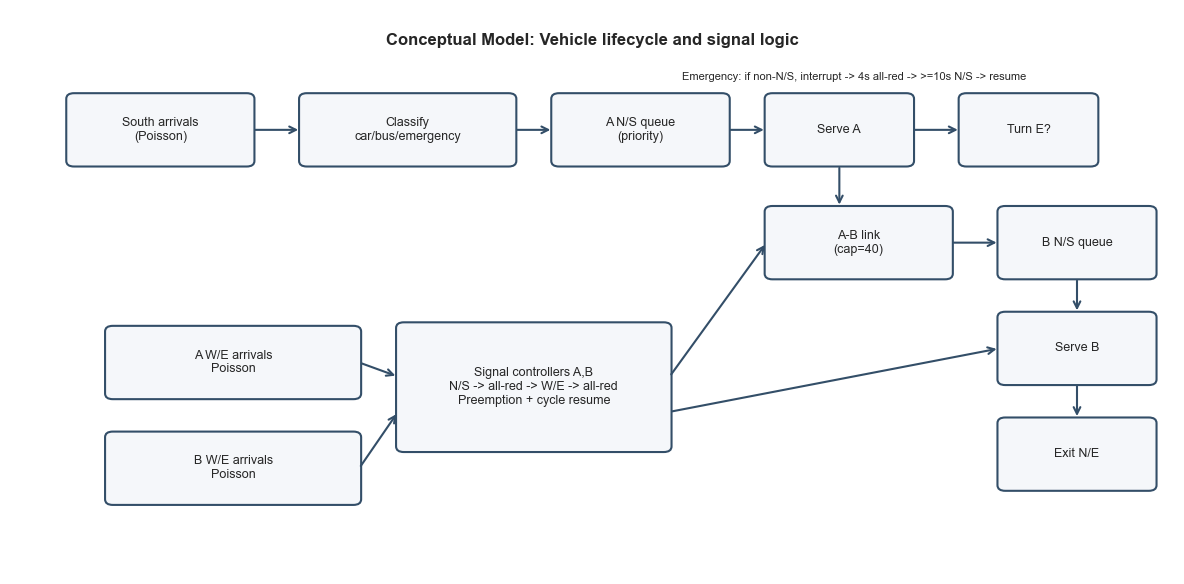

Saved: outputs/conceptual_model.png


In [13]:
# Generate conceptual model figure for report
from matplotlib.patches import FancyBboxPatch

fig, ax = plt.subplots(figsize=(12, 6))
ax.set_xlim(0, 12)
ax.set_ylim(0, 8)
ax.axis('off')

def box(x, y, w, h, text, fc='#f5f7fa', ec='#334e68'):
    p = FancyBboxPatch((x, y), w, h, boxstyle='round,pad=0.02,rounding_size=0.08',
                       linewidth=1.5, edgecolor=ec, facecolor=fc)
    ax.add_patch(p)
    ax.text(x + w/2, y + h/2, text, ha='center', va='center', fontsize=9)

def arrow(x1, y1, x2, y2):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', lw=1.5, color='#334e68'))

box(0.6, 5.8, 1.9, 1.0, 'South arrivals\n(Poisson)')
box(3.0, 5.8, 2.2, 1.0, 'Classify\ncar/bus/emergency')
box(5.6, 5.8, 1.8, 1.0, 'A N/S queue\n(priority)')
box(7.8, 5.8, 1.5, 1.0, 'Serve A')
box(9.8, 5.8, 1.4, 1.0, 'Turn E?')

box(7.8, 4.2, 1.9, 1.0, 'A-B link\n(cap=40)')
box(10.2, 4.2, 1.6, 1.0, 'B N/S queue')
box(10.2, 2.7, 1.6, 1.0, 'Serve B')
box(10.2, 1.2, 1.6, 1.0, 'Exit N/E')

box(1.0, 2.5, 2.6, 1.0, 'A W/E arrivals\nPoisson')
box(1.0, 1.0, 2.6, 1.0, 'B W/E arrivals\nPoisson')
box(4.0, 1.75, 2.8, 1.8, 'Signal controllers A,B\nN/S -> all-red -> W/E -> all-red\nPreemption + cycle resume')

arrow(2.5, 6.3, 3.0, 6.3)
arrow(5.2, 6.3, 5.6, 6.3)
arrow(7.4, 6.3, 7.8, 6.3)
arrow(9.3, 6.3, 9.8, 6.3)
arrow(8.55, 5.8, 8.55, 5.2)
arrow(9.7, 4.7, 10.2, 4.7)
arrow(11.0, 4.2, 11.0, 3.7)
arrow(11.0, 2.7, 11.0, 2.2)

arrow(3.6, 3.0, 4.0, 2.8)
arrow(3.6, 1.5, 4.0, 2.3)
arrow(6.8, 2.8, 7.8, 4.7)
arrow(6.8, 2.3, 10.2, 3.2)

ax.text(6.0, 7.5, 'Conceptual Model: Vehicle lifecycle and signal logic', ha='center', fontsize=12, weight='bold')
ax.text(8.7, 7.0, 'Emergency: if non-N/S, interrupt -> 4s all-red -> >=10s N/S -> resume', ha='center', fontsize=8)

plt.tight_layout()
plt.savefig('outputs/conceptual_model.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved: outputs/conceptual_model.png')

## Additional Graphics for Better Simulation Insight
The next cell creates extra visual diagnostics and saves them under outputs/.

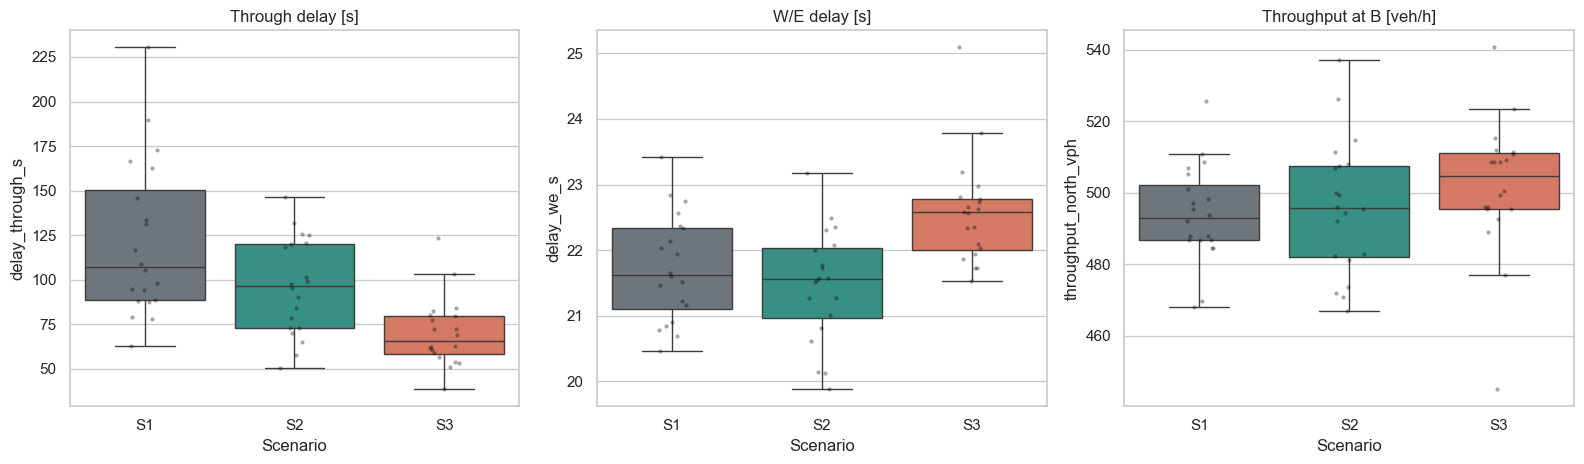

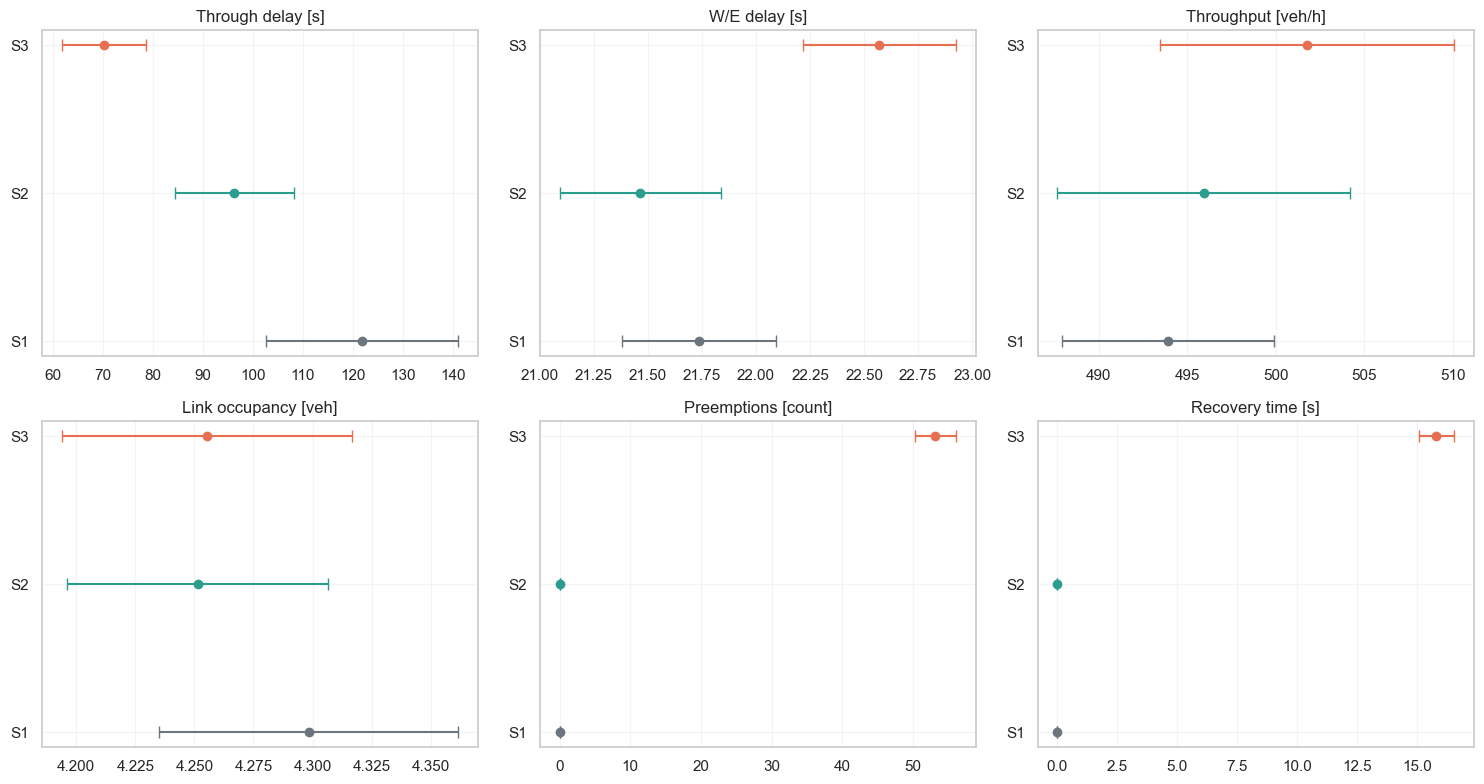

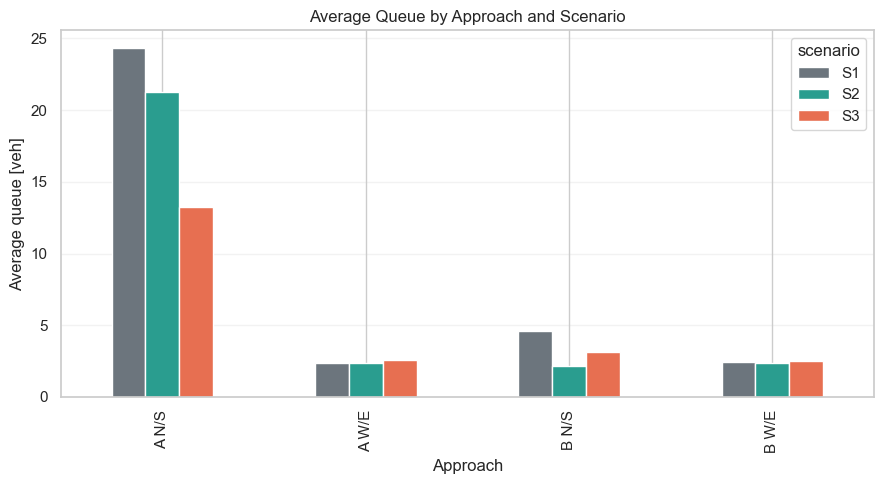

Saved graphics:
- outputs\fig_replication_variability.png
- outputs\fig_ci_comparison.png
- outputs\fig_queue_profile.png


In [14]:
# Additional explanatory graphics
from pathlib import Path

out_dir = Path('outputs')
out_dir.mkdir(parents=True, exist_ok=True)

# Ensure required data exists even in a fresh kernel state
if 'df_rep' not in globals():
    df_rep = pd.read_csv(out_dir / 'replication_results.csv')
if 'df_ci' not in globals():
    df_ci = pd.read_csv(out_dir / 'kpi_summary_ci95.csv')

scenario_order = ['Uncoordinated_NoEmergency', 'Coordinated_NoEmergency', 'Coordinated_WithEmergency']
scenario_short = {
    'Uncoordinated_NoEmergency': 'S1',
    'Coordinated_NoEmergency': 'S2',
    'Coordinated_WithEmergency': 'S3'
}
palette = {
    'Uncoordinated_NoEmergency': '#6c757d',
    'Coordinated_NoEmergency': '#2a9d8f',
    'Coordinated_WithEmergency': '#e76f51',
}

# 1) Replication variability: box + strip for key KPIs
metrics1 = [
    ('delay_through_s', 'Through delay [s]'),
    ('delay_we_s', 'W/E delay [s]'),
    ('throughput_north_vph', 'Throughput at B [veh/h]')
]
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
for ax, (m, title) in zip(axes, metrics1):
    sns.boxplot(
        data=df_rep,
        x='scenario', y=m,
        hue='scenario',
        order=scenario_order,
        hue_order=scenario_order,
        palette=palette,
        showfliers=False,
        legend=False,
        ax=ax,
    )
    sns.stripplot(
        data=df_rep,
        x='scenario', y=m,
        order=scenario_order,
        color='black',
        alpha=0.35,
        size=3,
        ax=ax,
    )
    ax.set_title(title)
    ax.set_xlabel('Scenario')
    ax.set_xticks(range(len(scenario_order)))
    ax.set_xticklabels([scenario_short[s] for s in scenario_order])
plt.tight_layout()
plt.savefig(out_dir / 'fig_replication_variability.png', dpi=200, bbox_inches='tight')
plt.show()

# 2) CI comparison chart (forest-like small multiples)
metrics2 = [
    ('delay_through_s', 'Through delay [s]'),
    ('delay_we_s', 'W/E delay [s]'),
    ('throughput_north_vph', 'Throughput [veh/h]'),
    ('avg_link_occupancy', 'Link occupancy [veh]'),
    ('preemption_count', 'Preemptions [count]'),
    ('recovery_time_s', 'Recovery time [s]'),
]
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, (m, title) in enumerate(metrics2):
    ax = axes[i]
    d = df_ci[df_ci['metric'] == m].copy()
    d['scenario'] = pd.Categorical(d['scenario'], categories=scenario_order, ordered=True)
    d = d.sort_values('scenario')
    y = np.arange(len(d))

    mean = d['mean'].to_numpy(dtype=float)
    lo = d['ci95_low'].to_numpy(dtype=float)
    hi = d['ci95_high'].to_numpy(dtype=float)

    for j in range(len(d)):
        if np.isfinite(mean[j]):
            left = mean[j] - lo[j] if np.isfinite(lo[j]) else 0.0
            right = hi[j] - mean[j] if np.isfinite(hi[j]) else 0.0
            ax.errorbar(mean[j], y[j], xerr=[[left], [right]], fmt='o', color=palette[d.iloc[j]['scenario']], capsize=4)

    ax.set_yticks(y)
    ax.set_yticklabels([scenario_short[s] for s in d['scenario']])
    ax.set_title(title)
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.savefig(out_dir / 'fig_ci_comparison.png', dpi=200, bbox_inches='tight')
plt.show()

# 3) Queue profile chart using mean queue KPIs
queue_map = {
    'avg_q_A_NS': 'A N/S',
    'avg_q_B_NS': 'B N/S',
    'avg_q_A_WE': 'A W/E',
    'avg_q_B_WE': 'B W/E',
}
q = df_ci[df_ci['metric'].isin(queue_map.keys())].copy()
q['approach'] = q['metric'].map(queue_map)
pivot_q = q.pivot(index='approach', columns='scenario', values='mean')[scenario_order]

fig, ax = plt.subplots(figsize=(9, 5))
pivot_q.rename(columns=scenario_short).plot(kind='bar', ax=ax, color=['#6c757d', '#2a9d8f', '#e76f51'])
ax.set_title('Average Queue by Approach and Scenario')
ax.set_xlabel('Approach')
ax.set_ylabel('Average queue [veh]')
ax.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.savefig(out_dir / 'fig_queue_profile.png', dpi=200, bbox_inches='tight')
plt.show()

print('Saved graphics:')
print('-', out_dir / 'fig_replication_variability.png')
print('-', out_dir / 'fig_ci_comparison.png')
print('-', out_dir / 'fig_queue_profile.png')

## Lecture-Style DES Verification Add-ons
This section adds explicit utilization and $\rho$ checks, a Little's Law consistency check, a short event/state trace using step-wise next-event advance, and a modeling-choice note.

In [15]:
# 1) Explicit utilization and rho checks per approach
horizon = RUN_LENGTH - WARMUP
mu_service = 1.0 / MEAN_SERVICE

util_cols = ['util_A_NS', 'util_B_NS', 'util_A_WE', 'util_B_WE']
rho_cols = ['rho_A_NS', 'rho_B_NS', 'rho_A_WE', 'rho_B_WE']

util_rho_summary = df_rep.groupby('scenario')[util_cols + rho_cols].mean().reset_index()

# Add nominal rho reference (where exogenous lambda is known)
rho_nominal = {
    'A_NS': LAMBDA_S / mu_service,
    'A_WE': LAMBDA_WE / mu_service,
    'B_WE': LAMBDA_WE / mu_service,
}

print('Service rate mu:', mu_service, 'veh/s')
print('Nominal rho references (lambda/(N*mu), N=1):', rho_nominal)
display(util_rho_summary)

# Basic stability flags
flags = []
for _, row in util_rho_summary.iterrows():
    scen = row['scenario']
    for c in util_cols:
        if row[c] > 1.0 + 1e-9:
            flags.append((scen, c, row[c], 'utilization > 1'))
    for c in rho_cols:
        if row[c] > 1.0 + 1e-9:
            flags.append((scen, c, row[c], 'rho > 1'))

if flags:
    print('Potential instability flags:')
    display(pd.DataFrame(flags, columns=['scenario', 'metric', 'value', 'issue']))
else:
    print('All approach-level utilization and rho means are below 1.0.')

Service rate mu: 0.5 veh/s
Nominal rho references (lambda/(N*mu), N=1): {'A_NS': 0.5, 'A_WE': 0.2222222222222222, 'B_WE': 0.2222222222222222}


,scenario,util_A_NS,util_B_NS,util_A_WE,util_B_WE,rho_A_NS,rho_B_NS,rho_A_WE,rho_B_WE
0,Coordinated_NoEmergency,0.502454,0.345658,0.222425,0.222763,0.499921,0.349429,0.222841,0.223079
1,Coordinated_WithEmergency,0.503231,0.349932,0.224484,0.221442,0.504317,0.352349,0.224413,0.222746
2,Uncoordinated_NoEmergency,0.502851,0.354016,0.225484,0.219694,0.499254,0.352270,0.223540,0.221873


All approach-level utilization and rho means are below 1.0.


In [16]:
# 2) Little's Law consistency check: combined W/E stream
# L ~= lambda * W using combined A_WE + B_WE queues and combined W/E wait times.
ll_df = df_rep.copy()
ll_df['L_we_total'] = ll_df['avg_q_A_WE'] + ll_df['avg_q_B_WE']
ll_df['lambda_we_total'] = ll_df['served_WE_total'] / (RUN_LENGTH - WARMUP)
ll_df['lambdaW_we'] = ll_df['lambda_we_total'] * ll_df['delay_we_s']
ll_df['ll_abs_error'] = (ll_df['L_we_total'] - ll_df['lambdaW_we']).abs()
ll_df['ll_rel_error_pct'] = 100.0 * ll_df['ll_abs_error'] / ll_df['L_we_total'].replace(0, np.nan)

ll_summary = ll_df.groupby('scenario')[['L_we_total', 'lambdaW_we', 'll_abs_error', 'll_rel_error_pct']].mean().reset_index()
display(ll_summary)

print('Interpretation: smaller Little\'s Law error means better consistency between observed queue level and wait-flow product.')

,scenario,L_we_total,lambdaW_we,ll_abs_error,ll_rel_error_pct
0,Coordinated_NoEmergency,4.788428,4.786085,0.003907,0.081168
1,Coordinated_WithEmergency,5.062251,5.046068,0.019616,0.384560
2,Uncoordinated_NoEmergency,4.848563,4.841663,0.006899,0.144441


Interpretation: smaller Little's Law error means better consistency between observed queue level and wait-flow product.


### Modeling Choice Note (Why custom queues, not only PriorityResource)
We kept explicit priority queues (`heapq`) for approaches because this model needs **joint gating** conditions that are difficult to express with only `PriorityResource` requests:
- service allowed only in the active signal phase,
- non-emergency A N/S vehicles blocked when downstream link is full,
- emergency-triggered signal interrupts with cycle-resume behavior.

This still follows SimPy process-interaction DES (event scheduling via `yield`, `env.step`, `env.run`) while making priority + signal + blocking logic transparent for teaching and debugging.

In [17]:
# 3) Concise event/state trace (next-event stepping for 300 s)
def run_event_state_trace(scenario, rep_id=1, until=300.0, max_rows=120):
    env = simpy.Environment()
    rngs = spawn_rngs(MASTER_SEED, scenario['id'], rep_id)
    metrics = Metrics(WARMUP, RUN_LENGTH, CYCLE)

    signal_A = SignalController(env, 'A', offset=0.0, emergency_enabled=scenario['emergency_enabled'], metrics=metrics)
    signal_B = SignalController(env, 'B', offset=scenario['offset_B'], emergency_enabled=scenario['emergency_enabled'], metrics=metrics)
    link = CorridorLink(env, metrics, travel_rng=rngs['service_A'], noise_rng=rngs['link_noise'])

    inter_A = Intersection(env, 'A', signal_A, metrics, rngs['service_A'], rngs['turn_A'], link=link)
    inter_B = Intersection(env, 'B', signal_B, metrics, rngs['service_B'], rngs['turn_B'], link=None)
    link.downstream_intersection = inter_B

    env.process(south_arrivals(env, inter_A, rngs['arrival_s'], rngs['classify'], rngs['turn_A'], scenario['emergency_enabled']))
    env.process(we_arrivals(env, inter_A, rngs['arrival_we_A']))
    env.process(we_arrivals(env, inter_B, rngs['arrival_we_B']))

    trace = []
    while env.peek() < until:
        env.step()  # next-event advance (lecture-style FEL stepping)
        if len(trace) < max_rows:
            trace.append({
                't': env.now,
                'phase_A': signal_A.phase_name,
                'phase_B': signal_B.phase_name,
                'q_A_NS': len(inter_A.ns_queue),
                'q_A_WE': len(inter_A.we_queue),
                'q_B_NS': len(inter_B.ns_queue),
                'q_B_WE': len(inter_B.we_queue),
                'link_occ': link.occupancy,
                'preempt_A_active': signal_A._handling_preemption,
                'preempt_B_active': signal_B._handling_preemption,
            })

    tr = pd.DataFrame(trace)
    tr['dt'] = tr['t'].diff().fillna(0.0)
    return tr

trace_df = run_event_state_trace(SCENARIOS[2], rep_id=1, until=300.0, max_rows=120)
print('Trace rows captured:', len(trace_df))
print('Time monotonic increasing:', bool((trace_df['dt'] >= 0).all()))
display(trace_df.head(20))
display(trace_df.tail(20))

Trace rows captured: 120
Time monotonic increasing: True


,t,phase_A,phase_B,q_A_NS,q_A_WE,q_B_NS,q_B_WE,link_occ,preempt_A_active,preempt_B_active,dt
0,0.000000,NS_GREEN,NaN,0,0,0,0,0,False,False,0.000000
1,0.000000,NS_GREEN,WE_GREEN,0,0,0,0,0,False,False,0.000000
2,0.000000,NS_GREEN,WE_GREEN,0,0,0,0,0,False,False,0.000000
3,0.000000,NS_GREEN,WE_GREEN,0,0,0,0,0,False,False,0.000000
4,0.000000,NS_GREEN,WE_GREEN,0,0,0,0,0,False,False,0.000000
5,0.000000,NS_GREEN,WE_GREEN,0,0,0,0,0,False,False,0.000000
6,0.000000,NS_GREEN,WE_GREEN,0,0,0,0,0,False,False,0.000000
7,0.000000,NS_GREEN,WE_GREEN,0,0,0,0,0,False,False,0.000000
8,0.000000,NS_GREEN,WE_GREEN,0,0,0,0,0,False,False,0.000000
9,0.000000,NS_GREEN,WE_GREEN,0,0,0,0,0,False,False,0.000000


,t,phase_A,phase_B,q_A_NS,q_A_WE,q_B_NS,q_B_WE,link_occ,preempt_A_active,preempt_B_active,dt
100,42.749461,NS_GREEN,NS_GREEN,1,9,0,3,1,False,False,2.096086
101,42.749461,NS_GREEN,NS_GREEN,1,9,0,3,1,False,False,0.000000
102,42.749461,NS_GREEN,NS_GREEN,0,9,0,3,1,False,False,0.000000
103,43.397578,NS_GREEN,NS_GREEN,0,9,0,3,1,False,False,0.648118
104,43.397578,NS_GREEN,NS_GREEN,0,9,0,3,2,False,False,0.000000
105,43.397578,NS_GREEN,NS_GREEN,0,9,0,3,2,False,False,0.000000
106,43.397578,NS_GREEN,NS_GREEN,0,9,0,3,2,False,False,0.000000
107,45.000000,ALL_RED,NS_GREEN,0,9,0,3,2,False,False,1.602422
108,45.000000,ALL_RED,NS_GREEN,0,9,0,3,2,False,False,0.000000
109,45.000000,ALL_RED,NS_GREEN,0,9,0,3,2,False,False,0.000000
